In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pyccl as ccl
from hmf import MassFunction

# ------------------------
# CONFIG
# ------------------------
h = 0.7 #1.0
sigma8 = 0.8
Om0 = 0.318
Ob0 = 0.04
n_s = 0.96

z_vals = np.arange(0.1, 1.0 + 1e-9, 0.1)
Mmin_log10, Mmax_log10, dlog10m = 13.0, 16.0, 0.01
log10M_msunh = np.arange(Mmin_log10, Mmax_log10 + 1e-9, dlog10m)
M_msunh = 10**log10M_msunh
M_msun = M_msunh / h  # convert to Msun for CCL
mask = (M_msunh >= 1e13) & (M_msunh <= 1e15)
#mask_noh = (M_msun >= 1e13*h) & (M_msun <= 1e15*h)


In [3]:
np.allclose(M_msun, M_msunh / h)

True

In [ ]:

# ------------------------
# CCL CONFIG
# ------------------------
cosmo_ccl = ccl.Cosmology(
    Omega_c=Om0 - Ob0,
    Omega_b=Ob0,
    h=h,
    n_s=n_s,
    sigma8=sigma8,
    Omega_k=0.0,
    Neff=3.044,
    m_nu=0.0,
    w0=-1.0,
    wa=0.0,
    T_CMB=2.7255,
    matter_power_spectrum="linear",
    transfer_function="eisenstein_hu",
)

hmf_ccl = ccl.halos.MassFuncTinker08(mass_def='200m')

def dndlnM_ccl(cosmo, M_msun, a):
    dndlog10M = hmf_ccl(cosmo, M_msun, a)  # dn/dlog10M [Mpc^-3]
    return dndlog10M / np.log(10.0) / h**3       # convert to dn/dlnM [(Mpc/h)^-3]

# compute grid
dndlnM_ccl_arr = np.empty((len(z_vals), len(M_msun)))
for i, z in enumerate(z_vals):
    a = 1.0 / (1.0 + z)
    dndlnM_ccl_arr[i] = dndlnM_ccl(cosmo_ccl, M_msun, a)

# rescale for h units
#dndlnM_ccl_h3 = dndlnM_ccl_arr  # dn/dlnM [h^3 Mpc^-3]; 
#dndlnM_ccl_h3 = dndlnM_ccl_arr * h**3 / h # to convert from dn/dlnM to dn/dlnM_h
'''
# Convert CCL from Msun to Msun/h grid
dndlnM_ccl_h3_interp = np.empty_like(dndlnM_ccl_arr)
for i, z in enumerate(z_vals):
    dndlnM_ccl_h3_interp[i] = np.interp(
        np.log(M_msunh),             # target grid in Msun/h
        np.log(M_msun),              # original CCL grid in Msun
        dndlnM_ccl_arr[i],            # dn/dlnM [h^3 Mpc^-3]
        left=np.nan, right=np.nan
    )
'''

# ------------------------
# HMF CONFIG
# ------------------------
dndlnM_hmf_arr = np.empty_like(dndlnM_ccl_arr)
for i, z in enumerate(z_vals):
    mf = MassFunction(
        z=z,
        cosmo_params={"H0": 100*h, "Om0": Om0, "Ob0": Ob0},
        sigma_8=sigma8,
        n=n_s,
        hmf_model='Tinker08',
        Mmin=Mmin_log10-3, Mmax=Mmax_log10+1, dlog10m=dlog10m,
        mdef_model="SOMean", mdef_params={"overdensity": 200}
    )
    # interpolate to match same mass grid
    dndlnM_hmf_arr[i] = np.interp(np.log(M_msunh), np.log(mf.m), mf.dndlnm)
    m_h = mf.m  # save mass array for plotting
    
# ------------------------
# COSMOSIS RESULTS
# ------------------------
# I got these files from including the module from cosmosis-standard-library/mass_function/mf_tinker and running cosmosis on a config file with the same cosmology as above.

# h=0.7 files
mass_cosmo = np.loadtxt('/global/homes/x/xintang/cosmosis-standard-library/mf_xt/mock_mf/results_mf_z01/mass_function/m_h.txt', comments='#')        # M_h [Msun/h]
dndlnmh_cosmo = np.loadtxt('/global/homes/x/xintang/cosmosis-standard-library/mf_xt/mock_mf/results_mf_z01/mass_function/dndlnmh.txt', comments='#')

'''
# h=1.0 files
mass_cosmo = np.loadtxt('/global/homes/x/xintang/cosmosis-standard-library/mf_xt/mock_mf/results_mf_z01_h1/mass_function/m_h.txt', comments='#')        # M_h [Msun/h]
dndlnmh_cosmo = np.loadtxt('/global/homes/x/xintang/cosmosis-standard-library/mf_xt/mock_mf/results_mf_z01_h1/mass_function/dndlnmh.txt', comments='#')
'''

# Ensure correct shape: (nz, nM)
dndlnmh_cosmo = np.asarray(dndlnmh_cosmo)
if dndlnmh_cosmo.shape[0] < dndlnmh_cosmo.shape[1]:
    dndlnmh_cosmo = dndlnmh_cosmo
    
# Interpolate Cosmosis results to match CCL/HMF mass grid
dndlnM_cosmo_interp = np.empty_like(dndlnM_ccl_arr)
for i, z in enumerate(z_vals):
    dndlnM_cosmo_interp[i] = np.interp(
        np.log(M_msunh),
        np.log(mass_cosmo),
        dndlnmh_cosmo[i],
        left=np.nan, right=np.nan
    )


/global/homes/x/xintang/anaconda3/envs/firecrown_clp/lib/python3.12/site-packages/hmf/density_field/transfer_models.py:232: UserWarning: 'extrapolate_with_eh' was not set. Defaulting to True, which is different behaviour than versions <=3.4.4. This warning may be removed in v4.0. Silence it by setting extrapolate_with_eh explicitly.
  warnings.warn(


In [49]:
print(hmf_ccl.mass_def)
# If it’s a MassDef object, inspect it:
md = hmf_ccl.mass_def
print(md.Delta, md.rho_type)   # expecting 200 and 'matter' (or similar)

MassDef(Delta=200, rho_type=matter)
200 matter


In [50]:
# pick one z (and a) and one mass grid point subset
zn = z_vals[0]
a = 1/(1+zn)

# choose a few masses to test
M_test_msun = np.array([1e12, 1e13, 1e14, 1e15])  # Msun

# CCL: get rho_m (comoving)
sigmaM_ccl = ccl.sigmaM(cosmo_ccl, M_test_msun, a)  # correct CCL σ(M)
print("CCL sigmaM:", sigmaM_ccl)

# after building mf at same z:
# mf.m is usually Msun/h. Convert it to Msun for comparing to M_test_msun
m_hmf_msun = mf.m * h

sigma_hmf = np.interp(np.log(M_test_msun), np.log(m_hmf_msun), mf.sigma)
print("HMF sigma(M):", sigma_hmf)

print(sigma_hmf/sigmaM_ccl)


CCL sigmaM: [2.12724215 1.47585982 0.94733968 0.54703816]
HMF sigma(M): [1.23042255 0.83332451 0.51691434 0.28590557]
[0.57841208 0.56463662 0.54564836 0.52264282]


In [51]:
print("CCL sigma8:", ccl.sigma8(cosmo_ccl))   # should be your sigma8

print("HMF sigma8:", mf.sigma_8)  

CCL sigma8: 0.800000000000001
HMF sigma8: 0.8


0.3788975842763839


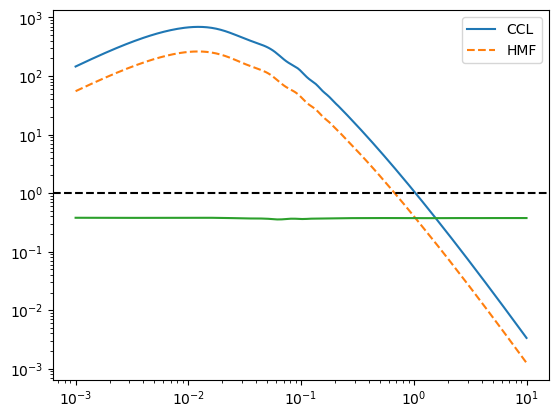

In [52]:

a = 1/(1+z_vals[0])
k = np.logspace(-3, 1, 200)  # 1/Mpc
pk_ccl = ccl.linear_matter_power(cosmo_ccl, k, a=1.0)

k_hmf = mf.k                 # h/Mpc
pk_hmf = mf.power            # (Mpc/h)^3
pk_hmf_Mpc3 = pk_hmf / h**3   # Mpc^3

k_hmf_Mpc = k_hmf * h          # 1/Mpc

pk_hmf_interp = np.interp(
    np.log(k),
    np.log(k_hmf_Mpc),
    pk_hmf_Mpc3,
    left=np.nan,
    right=np.nan
)

norm = pk_ccl[150]
pk_ccl_n = pk_ccl / norm
pk_hmf_n = pk_hmf_interp / norm

plt.loglog(k, pk_ccl_n, label="CCL")
plt.loglog(k, pk_hmf_n, ls="--", label="HMF")
plt.legend()

plt.semilogx(k, pk_hmf_interp / pk_ccl)
plt.axhline(1.0, color='k', ls='--')

print(pk_hmf_n[1]/pk_ccl_n[1])

ratio range: 0.3546536087189455 0.38062448976602464


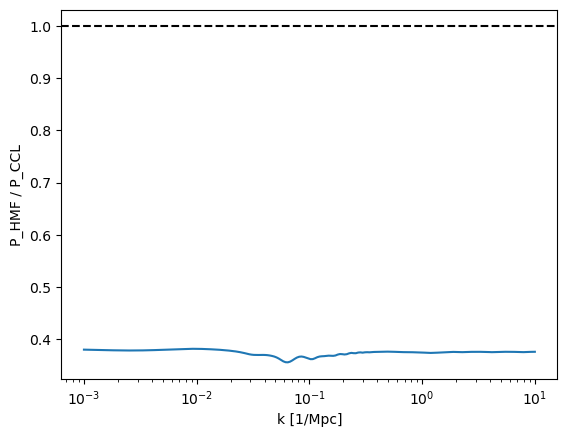

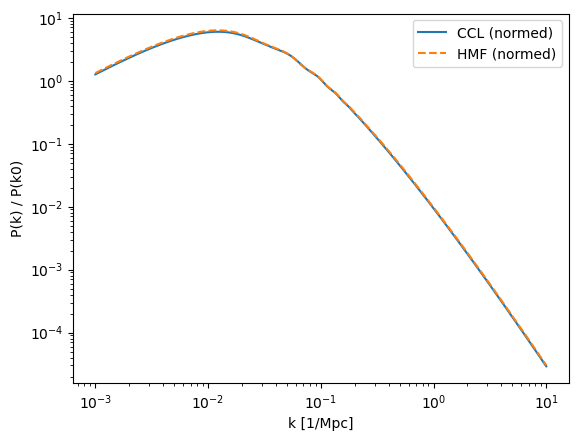

In [53]:
import numpy as np
import matplotlib.pyplot as plt
import pyccl as ccl

# --- choose a common k-grid in 1/Mpc
k = np.logspace(-3, 1, 200)  # 1/Mpc

# --- CCL P(k) at z=0 (a=1)
pk_ccl = ccl.linear_matter_power(cosmo_ccl, k, 1.0)  # Mpc^3

# --- HMF native k and P
k_hmf = mf.k          # h/Mpc
pk_hmf = mf.power     # (Mpc/h)^3

# --- convert HMF to CCL units: k->1/Mpc, P->Mpc^3
k_hmf_Mpc = k_hmf * h
pk_hmf_Mpc3 = pk_hmf / h**3

# --- interpolate HMF onto CCL k-grid
pk_hmf_interp = np.interp(np.log(k), np.log(k_hmf_Mpc), pk_hmf_Mpc3,
                          left=np.nan, right=np.nan)

# --- ratio in the overlap region
ratio = pk_hmf_interp / pk_ccl
maskn = np.isfinite(ratio)

print("ratio range:", np.nanmin(ratio[maskn]), np.nanmax(ratio[maskn]))

# --- plot: raw ratio
plt.figure()
plt.semilogx(k[maskn], ratio[maskn])
plt.axhline(1.0, color='k', ls='--')
plt.xlabel("k [1/Mpc]")
plt.ylabel("P_HMF / P_CCL")
plt.show()

# --- plot: shape-only (normalise each by its own value at same k index)
i0 = np.where(maskn)[0][len(np.where(maskn)[0])//2]  # middle valid point
pk_ccl_n = pk_ccl / pk_ccl[i0]
pk_hmf_n = pk_hmf_interp / pk_hmf_interp[i0]

plt.figure()
plt.loglog(k, pk_ccl_n, label="CCL (normed)")
plt.loglog(k, pk_hmf_n, ls="--", label="HMF (normed)")
plt.xlabel("k [1/Mpc]")
plt.ylabel("P(k) / P(k0)")
plt.legend()
plt.show()


In [54]:
k_Mpc = np.logspace(-3, 1, 200)            # 1/Mpc (CCL native)
pk_ccl_Mpc3 = ccl.linear_matter_power(cosmo_ccl, k_Mpc, 1.0)  # Mpc^3

# Convert CCL -> HMF units
k_ccl_hmpc = k_Mpc / h                     # h/Mpc
pk_ccl_mpc_h3 = pk_ccl_Mpc3 * h**3         # (Mpc/h)^3

# HMF native
k_hmf_hmpc = mf.k
pk_hmf_mpc_h3 = mf.power

# Interpolate CCL onto HMF k-grid and compare
pk_ccl_on_hmf = np.interp(np.log(k_hmf_hmpc), np.log(k_ccl_hmpc), pk_ccl_mpc_h3,
                          left=np.nan, right=np.nan)

ratio = pk_hmf_mpc_h3 / pk_ccl_on_hmf
print(np.nanmin(ratio), np.nanmax(ratio))


0.3542691980121922 0.38072978920660644


In [55]:
M_test_msun = np.array([1e12, 1e13, 1e14, 1e15])

sigma_ccl = ccl.sigmaM(cosmo_ccl, M_test_msun, a)

# HMF sigma is tabulated vs mf.m (Msun/h). Convert mf.m -> Msun:
m_hmf_msun = mf.m / h

sigma_hmf = np.interp(np.log(M_test_msun), np.log(m_hmf_msun), mf.sigma)

print("sigma ratio:", sigma_hmf/sigma_ccl)
print(h)


sigma ratio: [0.64346451 0.6423703  0.63960037 0.63675804]
0.7


In [56]:
# CCL: already have k (1/Mpc) and pk_ccl (Mpc^3)
Delta2_ccl = (k**3 * pk_ccl) / (2*np.pi**2)

# HMF: you had k_hmf_Mpc (1/Mpc) and pk_hmf_Mpc3 (Mpc^3) interpolated onto k_ccl
Delta2_hmf = (k**3 * pk_hmf_interp) / (2*np.pi**2)

ratio_Delta2 = Delta2_hmf / Delta2_ccl
print(np.nanmin(ratio_Delta2), np.nanmax(ratio_Delta2))

0.3546536087189455 0.38062448976602464


In [57]:
from colossus.cosmology import cosmology
from colossus.lss import mass_function as mfc

# set cosmology once (match what you used for CCL/HMF)
cosmo_params = {
    'flat'   : True,
    'H0'     : 100*h,
    'Om0'    : 0.3,
    'Ob0'    : 0.05,
    'sigma8' : 0.8,
    'ns'     : 0.96,
}
cosmology.setCosmology('mycosmo', cosmo_params)

# assume you already have:
# z_vals, M_msunh, mask
# shape: dndlnM_ccl_h3_interp[z,i], dndlnM_hmf_arr[z,i], dndlnM_cosmo_interp[z,i]

# compute Colossus HMF on the same mass grid and redshifts
dndlnM_colossus = np.zeros((len(z_vals), np.sum(mask)))

for i, z in enumerate(z_vals):
    dndlnM_colossus[i, :] = mfc.massFunction(
        M_msunh[mask], z,
        mdef  = '200m',     
        model = 'tinker08',
        q_out = 'dndlnM'
    )
    # if need h^3 Mpc^-3 and Colossus is in Mpc^-3, multiply by h**3 here
    # dndlnM_colossus[i, :] *= h**3


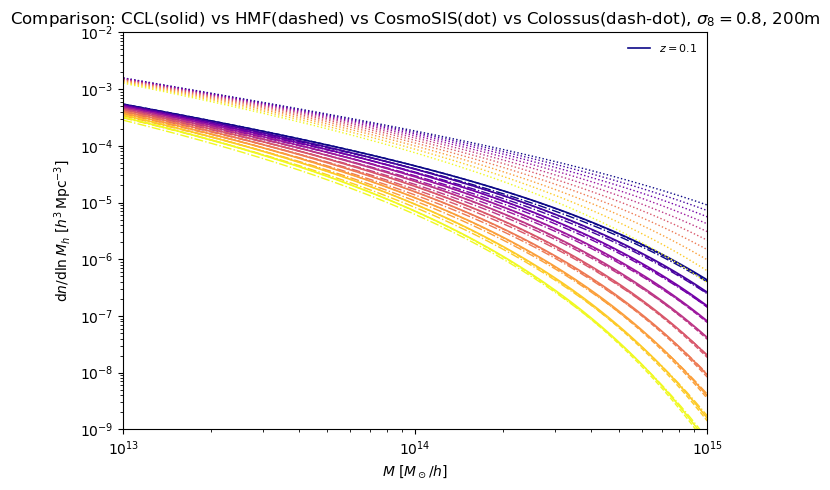

In [58]:
fig, ax = plt.subplots(figsize=(7,5))

import matplotlib.cm as cm
colors = cm.plasma(np.linspace(0, 1, len(z_vals)))

for i, z in enumerate(z_vals):
    color = colors[i]
    # solid = CCL
    ax.loglog(M_msunh[mask], dndlnM_ccl_arr[i, mask],
              '-', lw=1.2, color=color, label=fr'$z={z:.1f}$' if i == 0 else None)
    # dashed = HMF (hmf package)
    ax.loglog(M_msunh[mask], dndlnM_hmf_arr[i, mask],
              '--', lw=1.0, color=color)
    # dotted = CosmoSIS
    ax.loglog(M_msunh[mask], dndlnM_cosmo_interp[i, mask],
              ':', lw=1.0, color=color)
    # dash-dot = Colossus
    ax.loglog(M_msunh[mask], dndlnM_colossus[i, :],
              '-.', lw=1.0, color=color)

ax.set_xlim(1e13, 1e15)
ax.set_ylim(1e-9, 1e-2)
ax.set_xlabel(r'$M\ [M_\odot/h]$')
ax.set_ylabel(r'$\mathrm{d}n/\mathrm{d}\ln M_h\ [h^3\,\mathrm{Mpc}^{-3}]$')
ax.set_title(r'Comparison: CCL(solid) vs HMF(dashed) vs CosmoSIS(dot) vs Colossus(dash-dot), $\sigma_8=0.8$, 200m')
ax.legend(ncol=2, fontsize=8, frameon=False)
fig.tight_layout()
plt.show()


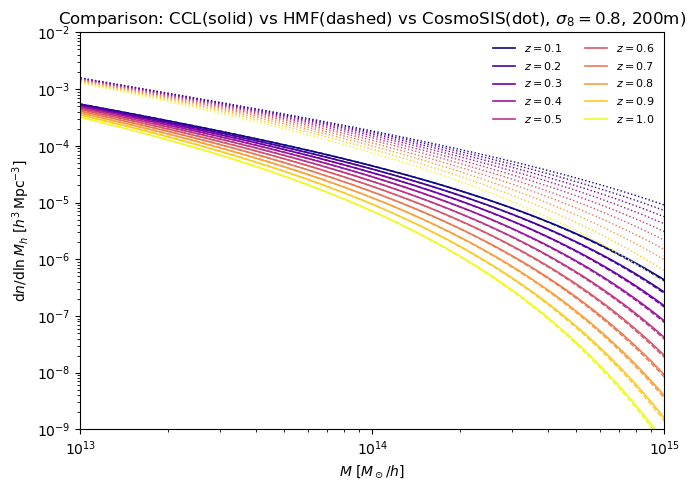

In [59]:
# ------------------------
# PLOT
# ------------------------
fig, ax = plt.subplots(figsize=(7,5))

import matplotlib.cm as cm

colors = cm.plasma(np.linspace(0, 1, len(z_vals)))  


for i, z in enumerate(z_vals):
    # solid = CCL, dashed = HMF
    color = colors[i]
    ax.loglog(M_msunh[mask], dndlnM_ccl_arr[i, mask], '-', lw=1.2, color=color, label=fr'$z={z:.1f}$')
    ax.loglog(M_msunh[mask], dndlnM_hmf_arr[i, mask], '--', lw=1.0, color=color)#, label=fr'HMF $z={z:.1f}$')
    ax.loglog(M_msunh[mask], dndlnM_cosmo_interp[i, mask], ':', lw=1.0, color=color)#, label=fr'CosmoSIS $z={z:.1f}$')

ax.set_xlim(1e13, 1e15)
ax.set_ylim(1e-9, 1e-2)
ax.set_xlabel(r'$M\ [M_\odot/h]$')
ax.set_ylabel(r'$\mathrm{d}n/\mathrm{d}\ln M_h\ [h^3\,\mathrm{Mpc}^{-3}]$')
ax.set_title(r'Comparison: CCL(solid) vs HMF(dashed) vs CosmoSIS(dot), $\sigma_8=0.8$, 200m)')
ax.legend(ncol=2, fontsize=8, frameon=False)
fig.tight_layout()
plt.show()

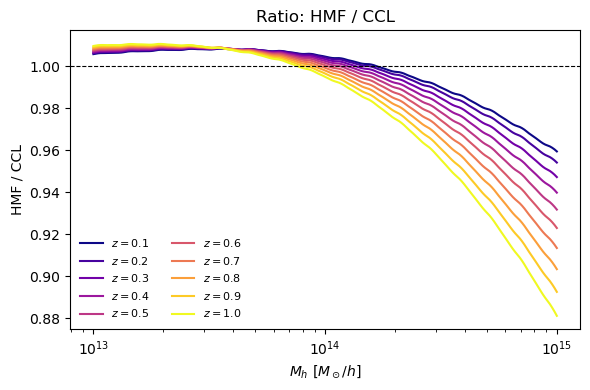

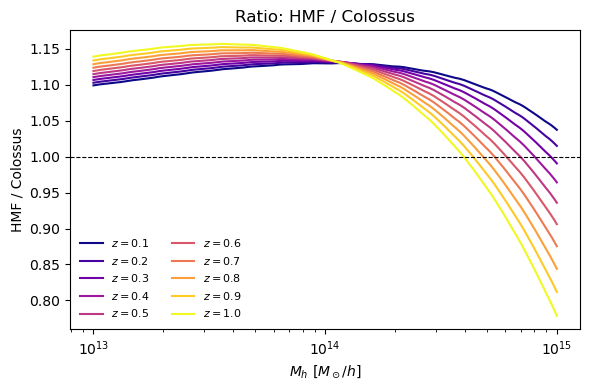

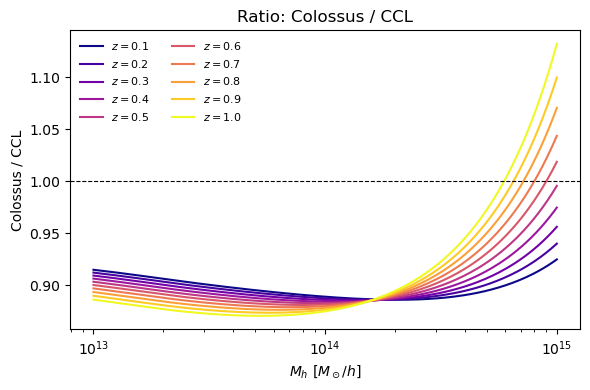

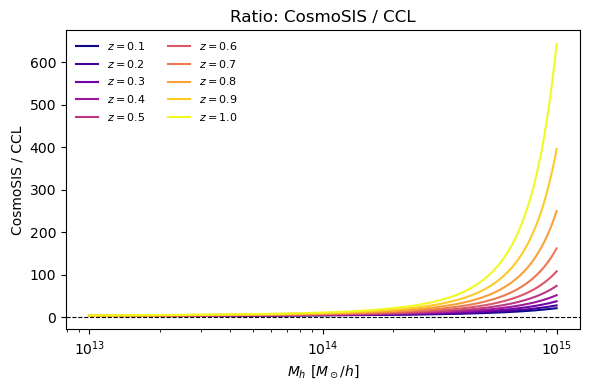

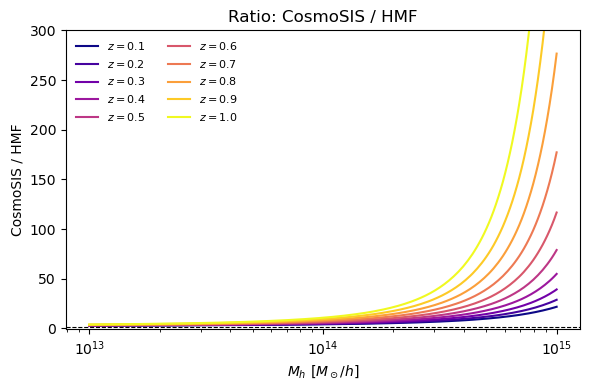

In [60]:
ratio_hmf_ccl    = dndlnM_hmf_arr        / dndlnM_ccl_arr
ratio_hmf_colossus = dndlnM_hmf_arr[:, mask] / dndlnM_colossus
ratio_colossus_ccl = dndlnM_colossus / dndlnM_ccl_arr[:, mask]
ratio_cosmo_ccl  = dndlnM_cosmo_interp   / dndlnM_ccl_arr
ratio_cosmo_hmf  = dndlnM_cosmo_interp   / dndlnM_hmf_arr

import matplotlib.cm as cm
colors = cm.plasma(np.linspace(0, 1, len(z_vals)))

# 1) HMF / CCL
fig, ax = plt.subplots(figsize=(6,4))
for i, z in enumerate(z_vals):
    ax.semilogx(M_msunh[mask], ratio_hmf_ccl[i, mask], color=colors[i], label=fr'$z={z:.1f}$')
ax.axhline(1, color='k', ls='--', lw=0.8)
ax.set_xlabel(r'$M_h\ [M_\odot/h]$')
ax.set_ylabel('HMF / CCL')
ax.set_title('Ratio: HMF / CCL')
ax.legend(ncol=2, fontsize=8, frameon=False)
fig.tight_layout()

# 1.1) HMF / Colossus
fig, ax = plt.subplots(figsize=(6,4))
for i, z in enumerate(z_vals):
    ax.semilogx(M_msunh[mask], ratio_hmf_colossus[i, :], color=colors[i], label=fr'$z={z:.1f}$')
ax.axhline(1, color='k', ls='--', lw=0.8)
ax.set_xlabel(r'$M_h\ [M_\odot/h]$')
ax.set_ylabel('HMF / Colossus')
ax.set_title('Ratio: HMF / Colossus')
ax.legend(ncol=2, fontsize=8, frameon=False)
fig.tight_layout()

# 1.2) Colossus / CCL
fig, ax = plt.subplots(figsize=(6,4))
for i, z in enumerate(z_vals):
    ax.semilogx(M_msunh[mask], ratio_colossus_ccl[i, :], color=colors[i], label=fr'$z={z:.1f}$')
ax.axhline(1, color='k', ls='--', lw=0.8)
ax.set_xlabel(r'$M_h\ [M_\odot/h]$')
ax.set_ylabel('Colossus / CCL')
ax.set_title('Ratio: Colossus / CCL')
ax.legend(ncol=2, fontsize=8, frameon=False)
fig.tight_layout()

# 2) CosmoSIS / CCL
fig, ax = plt.subplots(figsize=(6,4))
for i, z in enumerate(z_vals):
    ax.semilogx(M_msunh[mask], ratio_cosmo_ccl[i, mask], color=colors[i], label=fr'$z={z:.1f}$')
ax.axhline(1, color='k', ls='--', lw=0.8)
ax.set_xlabel(r'$M_h\ [M_\odot/h]$')
ax.set_ylabel('CosmoSIS / CCL')
ax.set_title('Ratio: CosmoSIS / CCL')
ax.legend(ncol=2, fontsize=8, frameon=False)
fig.tight_layout()

# 3) CosmoSIS / HMF
fig, ax = plt.subplots(figsize=(6,4))
for i, z in enumerate(z_vals):
    ax.semilogx(M_msunh[mask], ratio_cosmo_hmf[i, mask], color=colors[i], label=fr'$z={z:.1f}$')
ax.axhline(1, color='k', ls='--', lw=0.8)
ax.set_xlabel(r'$M_h\ [M_\odot/h]$')
ax.set_ylabel('CosmoSIS / HMF')
#ax.set_xlim(1e13, 1e14)
ax.set_ylim(-1, 300)
ax.set_title('Ratio: CosmoSIS / HMF')
ax.legend(ncol=2, fontsize=8, frameon=False)
fig.tight_layout()

plt.show()


In [61]:
print(dndlnM_hmf_arr.shape, dndlnM_colossus.shape)

(10, 301) (10, 201)
